# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [41]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [43]:
# mostrar las primeras 5 filas de plans

plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [44]:
# mostrar las primeras 5 filas de users

users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [45]:
# mostrar las primeras 5 filas de usage

usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [46]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [47]:
# inspección de plans con .info()

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [48]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [49]:
# inspección de usage con .info()

usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [50]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean().sort_values(ascending=False))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [51]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Comentario_Analista**

Las columnas nulas en dataset de users son: churn date con una proporción de 88,3% y city con un 11,7%.
En el caso de las columnas nulas del dataset de usage son: duration con una proporción del 55% y length con una proporción del 44%

Para los casos de las columnas de users, churndate se debe eliminar o ignorar por la proporción tan grande que tiene con respecto a los valores nulos y city sise debe invetigar mas a profundidad en dado caso de poderlos imputar

Para el caso de las columnas de usage, tanto duration y length tienen una proprocion media la cual se pueden investigar mas a fondo en dado caso de que estas columnas sean determinantes para el analisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [52]:
# explorar columnas numéricas de users

users[["user_id","age"]].describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,4000.0,11999.50000,1154.844867,10000.0,10999.75,11999.5,12999.25,13999.0
age,4000.0,33.73975,123.232257,-999.0,32.00,47.0,63.00,79.0


- La columna `user_id` presenta una alta variabilidad debido a su std. Adicional a eso, la media y la mediana son iguales
- La columna `age` la mediana es mayor que el promedio y tiene una variabilidad media con respecto a su std. Se evidencia un sentinels en con el dato del min (-999)

In [53]:
# explorar columnas numéricas de usage

usage[["id","user_id","duration","length"]].describe().T

,count,mean,std,min,25%,50%,75%,max
id,40000.0,20000.500000,11547.149720,1.0,10000.7500,20000.5,30000.25,40000.0
user_id,40000.0,12002.405975,1157.279564,10000.0,10996.0000,12013.0,13005.00,13999.0
duration,17924.0,5.202237,6.842701,0.0,1.4375,3.5,6.99,120.0
length,22104.0,52.127398,56.611183,0.0,37.0000,50.0,64.00,1490.0


- Las columnas `id` y `user_id`tienen un comportamiento muy parecido debido a que son ID´s donde la media y la mediana son iguales en ambos casos y 
- Las columnas `duration` y `lenght`, son columnas flotantes las cuales tienen una variabilidad media-baja y son mediana y media tienen un comportamiento muy similar

In [54]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe().T


,count,unique,top,freq
city,3531,7,Bogotá,808
plan,4000,2,Basico,2595


- La columna `city` tiene el 11,7% de valores nulos, 7 ciudades distintas y Bogota como ciudad predominante con una frecuencia de 808 registros
- La columna `plan` no contiene valores nulos, 2 planes unicos y el plan mas predominante es el Basico con un a frecuencia de 2595 registros

In [55]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` no tiene valores nulos, contiene 2 tipos unicos y el tipo mas frecuente es el **Text** con 22.092 registros



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Comentario_Analista**: En las columnas numericas de users se encontraron sentinels en la columna `age`. Ese valor se puede mantener para en su posterior analisis, e imputarlos con las diferentes formas. en las columnas de usage no se ven sentinels.

En cuanto a las columnas categóricas se encuentran valores nulos en el df **users** en un 11,7% pero en las columnas de **usage** no se evidencian valores ausentes o inválidos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [56]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [57]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [58]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se ve registros de 4 años, desde 2022, 2023, 2024 y 2026. la mayor cantidad de datos se concentran en 2022-2024

In [59]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date`, se evidencia que solo tenemos datos del año 2024 y 50 registros que no contienen fechas, es decir, NAT.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Con base en la información que nos suministra la empresa, tenemos años que no harían parte del análisis, como lo es el 2026, en el cual tenemos 40 registros. Siguiendo lineamiento, excluiríamos esos registros de 2026 y nos enfocaríamos en los años 2022-2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [60]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [61]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [62]:

# Marcar fechas futuras como NA para reg_date
fechas_2026=users['reg_date'].dt.year == 2026
users.loc[fechas_2026,'reg_date']=pd.NaT


# Verificar cambios
print("Valores NaT:", users['reg_date'].isna().sum())
users['reg_date'].dt.year.value_counts()

Valores NaT: 40


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [63]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [64]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Los valores faltantes de `duration` y `length`dependen de la variable observada **type**, lo que evidencia que son MAR. Dado que la ausencia de información puede explicarse por variables presentes en el conjunto de datos, se optó por mantener los valores nulos y no realizar imputaciones, evitando alterar la distribución original de la información.`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [65]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(usage['user_id'])\
                    .agg(cant_mensajes= ('is_text', 'sum'),\
                       cant_llamadas=('is_call', 'sum'),\
                        cant_minutos_llamada=('duration', 'sum'))\
            .reset_index()

# observar resultado
print(usage_agg.shape)
usage_agg.head(3)


(3999, 4)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [66]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')
user_profile.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
3615,13615,Ana,Ramirez,40.0,NaN,2024-09-16 20:29:20.840210064,Premium,NaN,2.0,4.0,25.98
2523,12523,Mateo,Garcia,61.0,MTY,2023-11-22 20:15:18.229557392,Basico,NaN,1.0,4.0,10.93
290,10290,Mariana,Gomez,75.0,NaN,2022-03-21 09:46:35.198799700,Premium,"1,71772E+18",5.0,3.0,9.08
2004,12004,Mateo,Ramirez,42.0,Cali,2023-07-03 17:34:20.615153792,Basico,"1,73422E+18",5.0,6.0,9.69
2154,12154,Mariana,Torres,36.0,Bogotá,2023-08-13 19:19:07.786946736,Basico,NaN,4.0,3.0,24.99


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [67]:
# Resumen estadístico de las columnas numéricas

user_profile[['user_id','age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,4000.0,11999.500000,1154.844867,10000.0,10999.75,11999.50,12999.250,13999.00
age,4000.0,48.122250,17.690408,18.0,33.00,47.00,63.000,79.00
cant_mensajes,3999.0,5.524381,2.358416,0.0,4.00,5.00,7.000,17.00
cant_llamadas,3999.0,4.478120,2.144238,0.0,3.00,4.00,6.000,15.00
cant_minutos_llamada,3999.0,23.317054,18.168095,0.0,11.12,19.78,31.415,155.69


In [68]:
# Distribución porcentual del tipo de plan

user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

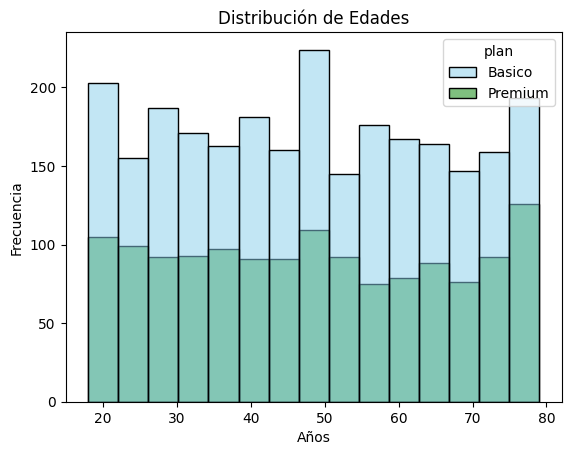

In [69]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, bins=15, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edades')
plt.ylabel('Frecuencia')
plt.xlabel('Años')
plt.show()

💡Insights: 
- Distribución normal, la cual tiene un pico donde se concentran la mayor cantidad de datos en las edades de 45 a 50 años, donde predomina en todas las edades el plan Premium en una pequeña proporcion

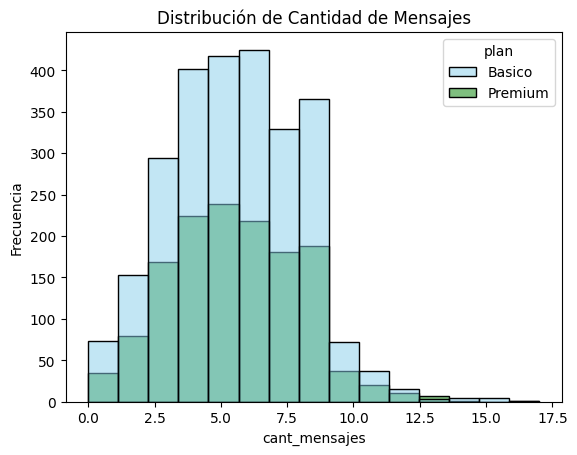

In [70]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, bins=15, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Es una distribución sesgada a la derecha, donde sigue predominando en menor medida el plan premium en todos los rangos de cantidades de mensajes. Se ve mas esa predominancia en los valores altos. Se los datos se concentran en 4 a 8 mensajes 

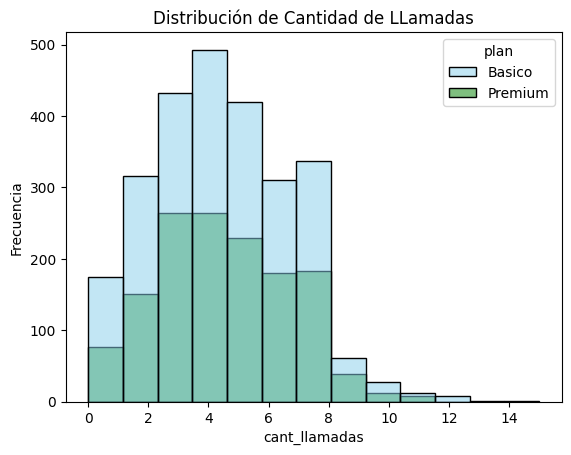

In [71]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, bins=13, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de LLamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, que concentra la mayor proporción de datos en el rango de 2 a 6 llamadas. La distribución por planes es muy parecida y donde se ve una diferencia es el rango de 8 a 12 llamadas donde hay una pequeña ventaja en el plan Premium

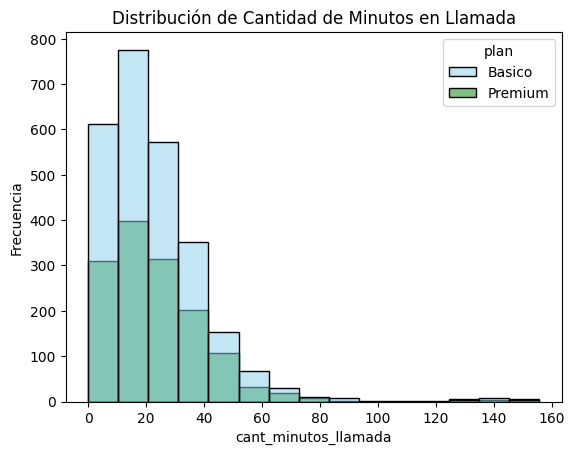

In [72]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, bins=15, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Minutos en Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha
- la mayor cantidad de datos que se registran tienen una duración max de una hora
- los planes premium se ven mas evidenciados en llamadas de los 60 minutos en adelante

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

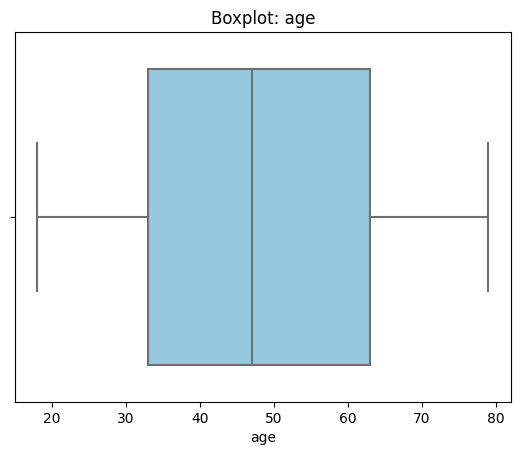

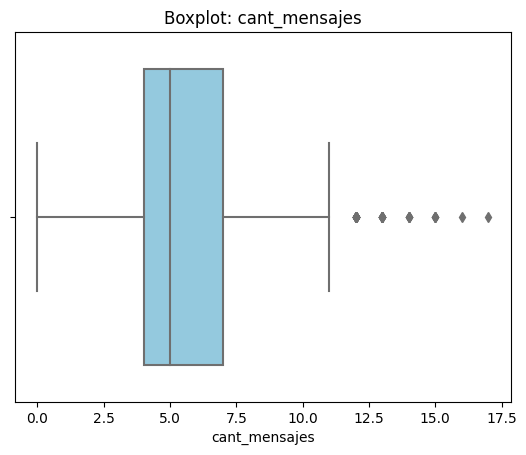

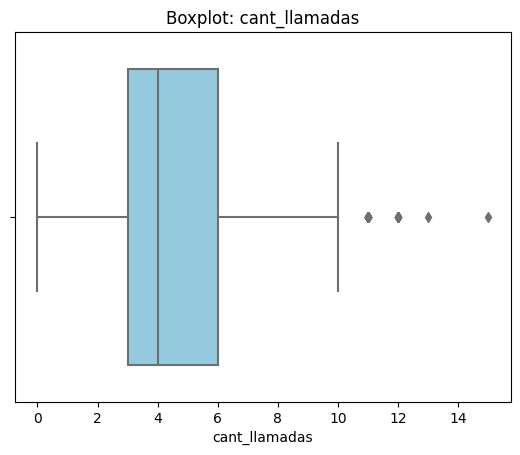

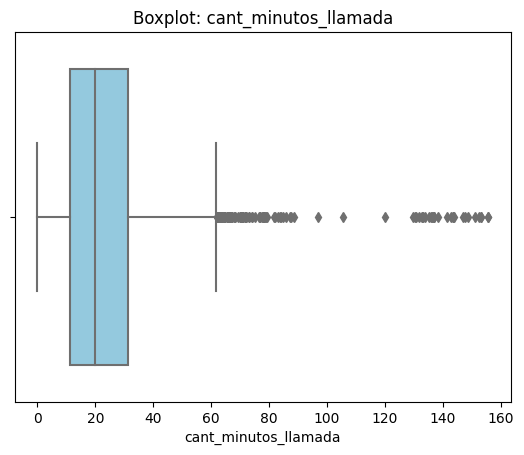

In [74]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: no presenta Outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta Outliers
- cant_minutos_llamada: Presenta outliers

In [84]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    print(f'Limite inferior de {col}:{lower}')
    upper=Q3+1.5*IQR
    print(f'Limite superior de {col}: {upper}')

Limite inferior de cant_mensajes:-0.5
Limite superior de cant_mensajes: 11.5
Limite inferior de cant_llamadas:-1.5
Limite superior de cant_llamadas: 10.5
Limite inferior de cant_minutos_llamada:-19.322500000000005
Limite superior de cant_minutos_llamada: 61.8575


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Aunque existen valores superiores al límite calculado por el método IQR (11.5), el máximo observado es de 17 mensajes, una cantidad razonable dentro del comportamiento esperado de un usuario. No hay evidencia de errores de captura ni de valores extremadamente alejados de la distribución, por lo que se conservan los registros para no perder información relevante sobre usuarios con mayor actividad
- cant_llamadas: De igual manera, se logra ver un comportamiento similar a cant_mensajes, donde no se encuentra valores extremadamente altos al IQR (10.5) donde el maximo es 15. Por esa misma razon, se mantienen
- cant_minutos_llamada: Aunque el método IQR identifica valores atípicos por encima de 61.86 minutos, el máximo registrado (155.69 minutos) corresponde a una duración posible dentro del servicio telefónico. Estos valores pueden corresponder a usuarios con un uso intensivo del servicio y no necesariamente a errores de medición o de captura. Se mantienen los datos pero es necesario hacer un analisis mas a fondo y documentarlos en dado caso

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [87]:
# Crear columna grupo_uso

def classify_segment(row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']

    #Segmentacion de Bajo uso
    if llamadas<5 and mensajes<5:
            return 'Bajo uso'

    #Segmentacion uso medio
    elif llamadas<10 and mensajes<10:
            return 'Uso medio'

    #segmentacion Alto uso
    else:
        return 'Alto uso'

#aplicar funcion
user_profile['grupo_uso']= user_profile.apply(classify_segment, axis=1)

    

In [90]:
# verificar cambios
user_profile.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
2015,12015,Sofia,Gomez,59.0,Bogotá,2023-07-06 17:51:37.674418608,Basico,NaN,6.0,7.0,21.47,Uso medio
3322,13322,Mariana,Garcia,26.0,Bogotá,2024-06-28 14:59:51.897974496,Premium,NaN,3.0,5.0,56.85,Uso medio
1329,11329,Mateo,Lopez,48.0,<NA>,2022-12-30 21:42:48.342085524,Basico,NaN,5.0,8.0,35.47,Uso medio
3362,13362,Mateo,Lopez,20.0,Bogotá,2024-07-09 13:51:48.477119280,Premium,NaN,4.0,4.0,24.58,Bajo uso
2174,12174,Mateo,Ramirez,49.0,CDMX,2023-08-19 06:45:06.076519136,Basico,NaN,7.0,6.0,15.05,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [91]:
# Crear columna grupo_edad

def classify_age(row):
    edades=row['age']

    #Segmentacion de Bajo uso
    if edades <30:
            return 'Joven'

    #Segmentacion uso medio
    elif edades<60:
            return 'Adulto'

    #segmentacion Alto uso
    else:
        return 'Adulto Mayor'

#aplicar funcion
user_profile['grupo_edad']= user_profile.apply(classify_age, axis=1)


In [92]:
# verificar cambios
user_profile.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
3296,13296,Ana,Garcia,35.0,Bogotá,2024-06-21 12:08:06.121530384,Basico,"1,71893E+18",7.0,3.0,21.21,Uso medio,Adulto
768,10768,Luis,Ramirez,22.0,Bogotá,2022-07-30 07:01:18.319579896,Basico,NaN,2.0,2.0,2.22,Bajo uso,Joven
2046,12046,Luis,Ramirez,45.0,MTY,2023-07-15 05:34:53.023255816,Basico,"1,72074E+18",4.0,4.0,32.56,Bajo uso,Adulto
3838,13838,Sofia,Garcia,78.0,Bogotá,2024-11-16 21:57:55.768942240,Basico,NaN,8.0,5.0,26.52,Uso medio,Adulto Mayor
2584,12584,Mateo,Gomez,71.0,Bogotá,2023-12-09 13:07:31.012753192,Basico,NaN,3.0,4.0,18.46,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

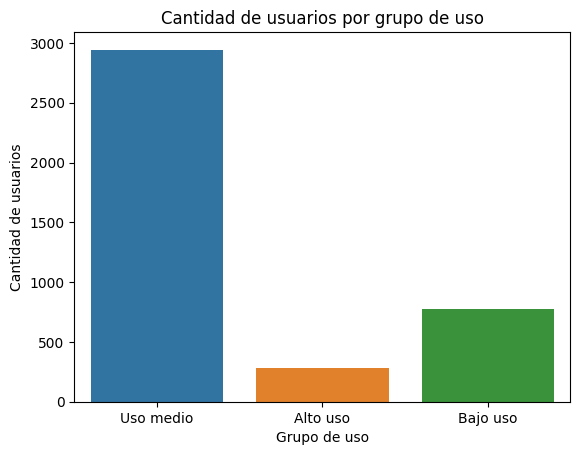

In [93]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Cantidad de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

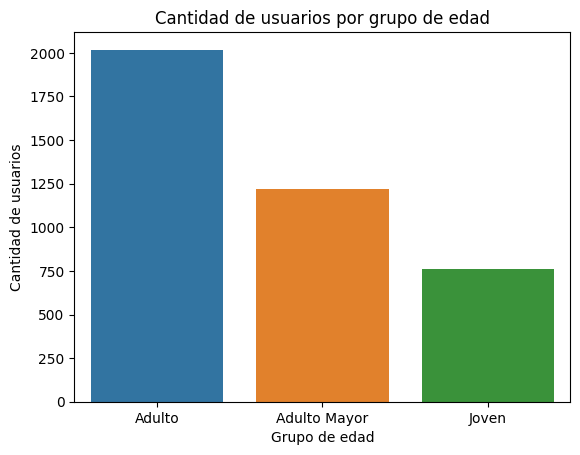

In [94]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Cantidad de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Había errores de tipo de datos  tanto en users como en usage en las columnas de fecha (reg_date y date). Churn_date también, pero al ser una columna con el 88% de datos vacíos, se excluyó del análisis. Adicional a esto, la columna reg_date tenía datos que no hacían parte del analisis, ya que contenían fechas del año 2026 (40 registros)

Se encontraron valores inválidos o sentinels en la columna age (-999) los cuales se imputaron con la mediana.La columna city tenía un 11,7%  "?" , los cuales se imputaron y se dejatona como NA

Las columnas length y duration se mantuvieron para a pesar de la cantidad de nulos que tenían ya que representaban columnas importantes para el análisis 

¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos tipos principales de segmentación:

**Segmentación por edad**
Adultos: aproximadamente 2.000 usuarios (grupo predominante).
Adultos mayores: aproximadamente 1.200 usuarios.
Jóvenes: aproximadamente 750 usuarios.

**Segmentación por nivel de uso**
Uso medio: aproximadamente 2.950 usuarios (grupo predominante).
Bajo uso: aproximadamente 770 usuarios.
Alto uso: aproximadamente 280 usuarios.

Esto indica que la mayoría de los clientes presentan patrones de consumo moderados, mientras que los usuarios intensivos representan una proporción relativamente pequeña de la base total.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El segmento de uso medio  es **estratégico** porque representa aproximadamente tres cuartas partes de la base de clientes. Pequeños incrementos en su consumo podrían generar un impacto importante en los ingresos totales de la compañía.

Sin embargo:

Alto uso: mayor valor individual.
Uso medio: mayor valor agregado por volumen de clientes.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Los Outliers fueron conservados porque representan comportamientos coherente dentro del negocio y no parecen corresponder a errores de captura.

Implicaciones para el negocio

Los outliers sugieren la existencia de usuarios altamente activos que:

Utilizan el servicio con mucha mayor intensidad que el promedio.
Podrían requerir planes especializados.
Son candidatos para programas de fidelización o beneficios adicionales.
Permiten identificar oportunidades de monetización mediante planes premium o ilimitados.

Especialmente en los minutos de llamada, donde algunos usuarios consumen más del doble del límite superior calculado mediante IQR.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Error en tipo de datos como fechas (reg_date, date y churn_date)
- Churn_date contenía el 88% de datos nulos. Por lo cual, se explique esa columna del analisis
- reg_date contenía datos del 2026 (40 registros)
- sentinels en la columna age (-999) y city (?)

🔍 **Segmentos por Edad**
- Adulto (predominante ~ 2000 registros)
- Adulto Mayor
- Joven

📊 **Segmentos por Nivel de Uso**
- Uso Medio (predominante por volumen)
- Uso ALto (segmento valioso por cantidad de minutos)
- Uso Bajo


💡 **Recomendaciones**
La recomendación más conveniente para ConnectaTel es mantener una oferta diferenciada por intensidad de uso, enfocando la rentabilidad en los usuarios de alto consumo y desarrollando acciones de crecimiento sobre el amplio segmento de uso medio, que constituye la mayor parte de la base de clientes. Esto permitiría maximizar ingresos sin descuidar la retención de clientes de bajo consumo

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`